In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("eBay_subasta.csv")
df

,Category,currency,sellerRating,Duration,endDay,ClosePrice,OpenPrice,Competitive
0,Music/Movie/Game,US,3249,5,Mon,0.01,0.01,0
1,Music/Movie/Game,US,3249,5,Mon,0.01,0.01,0
2,Music/Movie/Game,US,3249,5,Mon,0.01,0.01,0
3,Music/Movie/Game,US,3249,5,Mon,0.01,0.01,0
4,Music/Movie/Game,US,3249,5,Mon,0.01,0.01,0
...,...,...,...,...,...,...,...,...
1967,Automotive,US,2992,5,Sun,359.95,359.95,0
1968,Automotive,US,21,5,Sat,610.00,300.00,1
1969,Automotive,US,1400,5,Mon,549.00,549.00,0
1970,Automotive,US,57,7,Fri,820.00,650.00,1


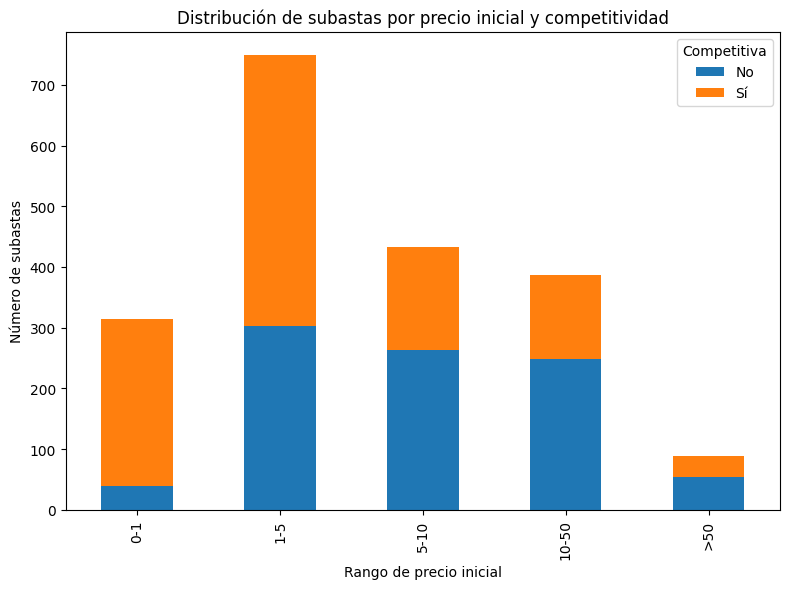

In [ ]:
bins_price = [0, 1, 5, 10, 50, df["OpenPrice"].max()]
labels_price = ["0-1", "1-5", "5-10", "10-50", ">50"]
df["price_bin"] = pd.cut(df["OpenPrice"], bins=bins_price, labels=labels_price, include_lowest=True)

# Contar por grupo
counts = df.groupby(["price_bin", "Competitive"]).size().unstack(fill_value=0)

# Graficar stacked bar chart
counts.plot(kind="bar", stacked=True, figsize=(8,6), color=["#1f77b4", "#ff7f0e"])
plt.title("Distribución de subastas por precio inicial y competitividad")
plt.xlabel("Rango de precio inicial")
plt.ylabel("Número de subastas")
plt.legend(title="Competitiva", labels=["No", "Sí"])
plt.tight_layout()
plt.show()




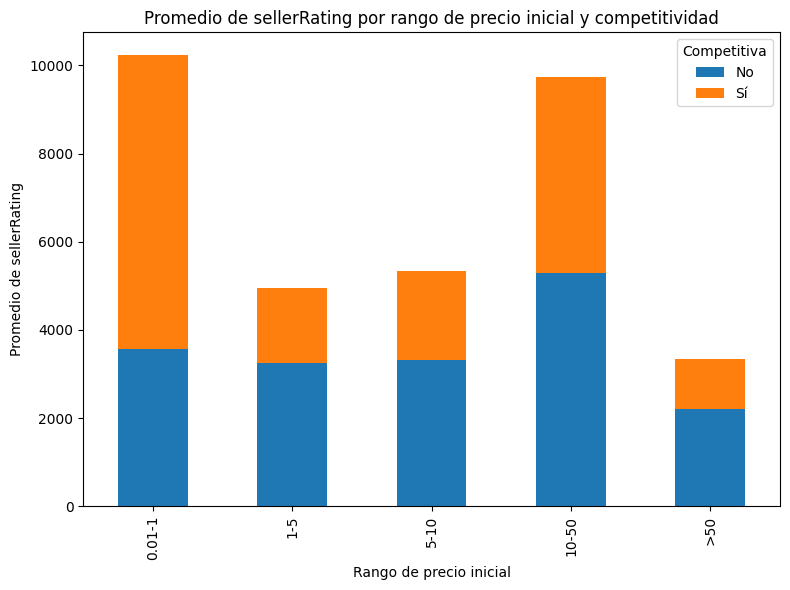

In [ ]:
bins_price = [0, 1, 5, 10, 50, df["OpenPrice"].max()]
labels_price = ["0.01-1", "1-5", "5-10", "10-50", ">50"]
df["price_bin"] = pd.cut(df["OpenPrice"], bins=bins_price, labels=labels_price, include_lowest=True)

avg_rating = df.groupby(["price_bin", "Competitive"])["sellerRating"].mean().unstack(fill_value=0)

avg_rating.plot(kind="bar", stacked=True, figsize=(8,6), color=["#1f77b4", "#ff7f0e"])
plt.title("Promedio de sellerRating por rango de precio inicial y competitividad")
plt.xlabel("Rango de precio inicial")
plt.ylabel("Promedio de sellerRating")
plt.legend(title="Competitiva", labels=["No", "Sí"])
plt.tight_layout()
plt.show()



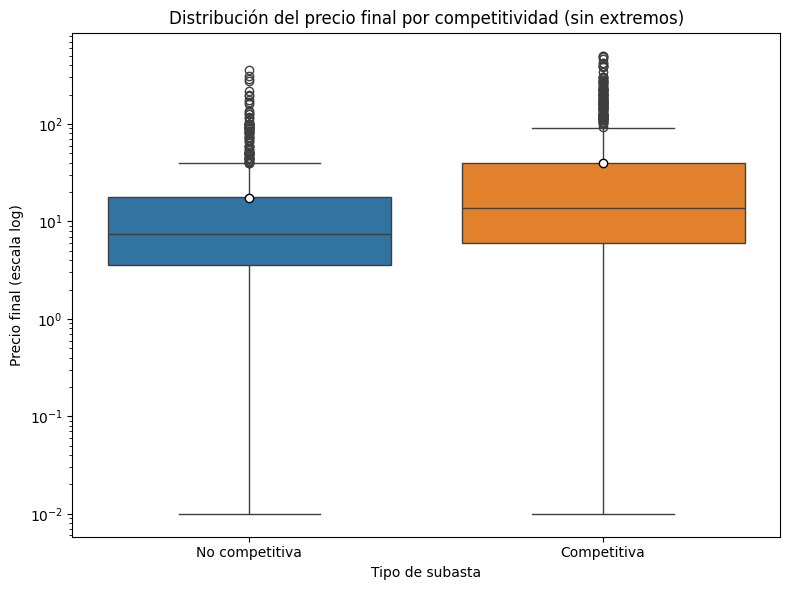

In [18]:

# === 2. Detectar automáticamente la columna de precio final ===
final_price_col = None
for candidate in ["FinalPrice", "ClosePrice", "Price", "SalePrice"]:
    if candidate in df.columns:
        final_price_col = candidate
        break

if final_price_col is None:
    raise ValueError("No se encontró columna de precio final. Revisa df.columns para confirmar el nombre.")

# === 3. Filtrar outliers extremos (1% inferior y superior) ===
q_low = df[final_price_col].quantile(0.01)
q_high = df[final_price_col].quantile(0.99)
df_filtered = df[(df[final_price_col] >= q_low) & (df[final_price_col] <= q_high)]

# === 4. Etiquetas claras para competitividad ===
df_filtered["Competitive_label"] = df_filtered["Competitive"].map({0: "No competitiva", 1: "Competitiva"})

# === 5. Crear boxplot optimizado ===
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_filtered,
    x="Competitive_label",
    y=final_price_col,
    palette=["#1f77b4", "#ff7f0e"],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)

# Escala logarítmica y títulos
plt.yscale('log')
plt.title("Distribución del precio final por competitividad (sin extremos)")
plt.xlabel("Tipo de subasta")
plt.ylabel("Precio final (escala log)")
plt.tight_layout()
plt.show()


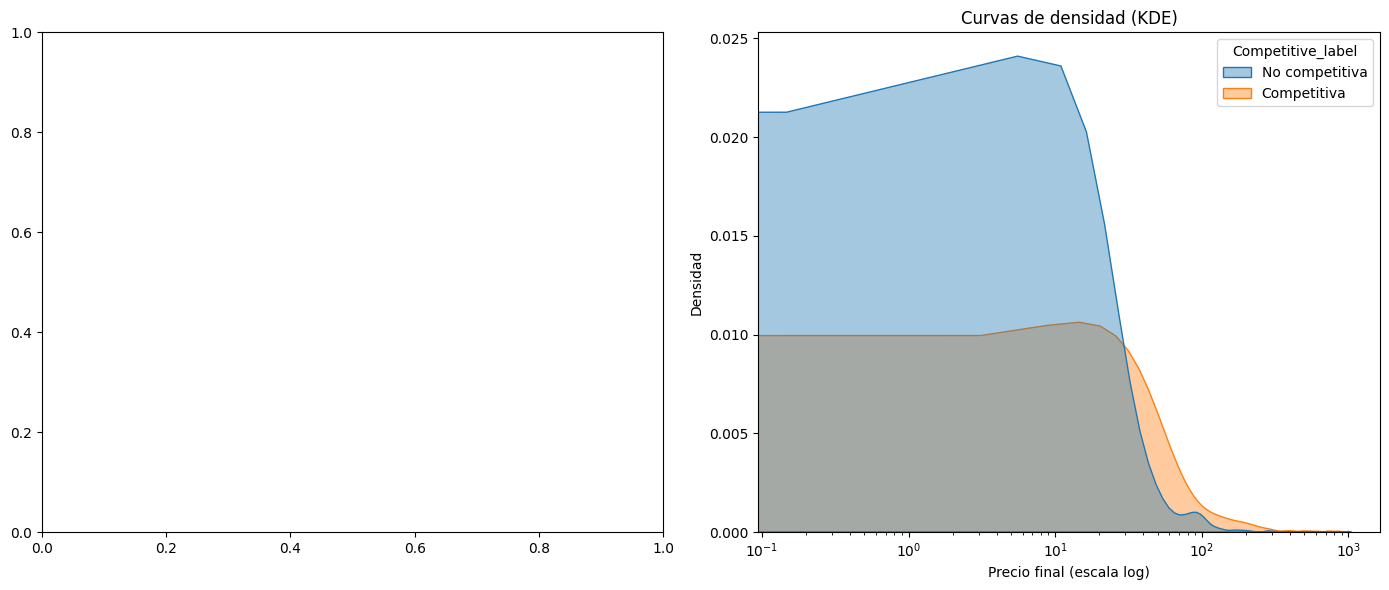

In [24]:

# === 2. Detectar automáticamente la columna de precio final ===
final_price_col = None
for candidate in ["FinalPrice", "ClosePrice", "Price", "SalePrice"]:
    if candidate in df.columns:
        final_price_col = candidate
        break

if final_price_col is None:
    raise ValueError("No se encontró columna de precio final. Revisa df.columns para confirmar el nombre.")

# === 3. Etiquetas claras para competitividad ===
df["Competitive_label"] = df["Competitive"].map({0: "No competitiva", 1: "Competitiva"})

# === 4. Crear figura con dos subplots ===
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Curvas de densidad (KDE) ---
sns.kdeplot(
    data=df,
    x="ClosePrice",
    hue="Competitive_label",
    fill=True,
    alpha=0.4,
    palette=["#1f77b4", "#ff7f0e"],
    common_norm=False,
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title("Curvas de densidad (KDE)")
axes[1].set_xlabel("Precio final (escala log)")
axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()



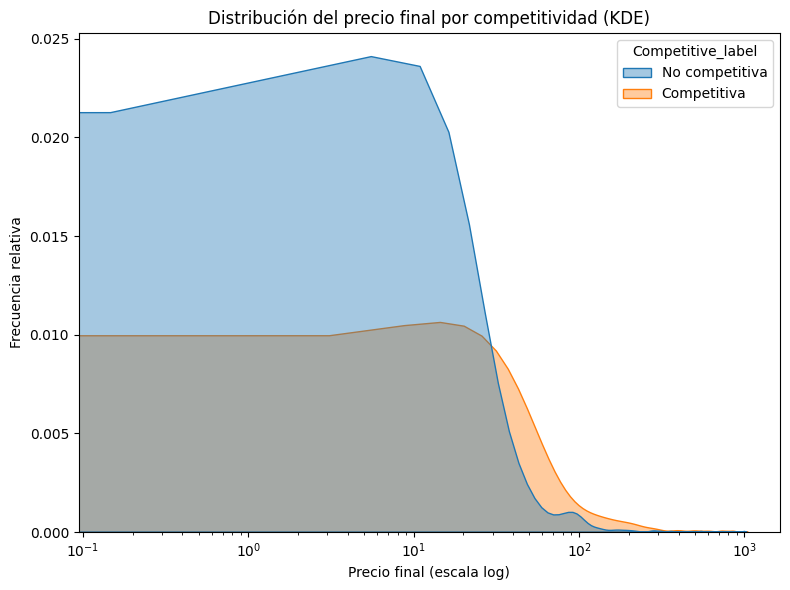

In [29]:
# === 3. Etiquetas claras para competitividad ===
df["Competitive_label"] = df["Competitive"].map({0: "No competitiva", 1: "Competitiva"})

# === 4. Gráfico KDE ===
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df,
    x="ClosePrice",
    hue="Competitive_label",
    fill=True,
    alpha=0.4,
    palette=["#1f77b4", "#ff7f0e"],
    common_norm=False
)

# Escala logarítmica y títulos
plt.xscale('log')
plt.title("Distribución del precio final por competitividad (KDE)")
plt.xlabel("Precio final (escala log)")
plt.ylabel("Frecuencia relativa")
plt.tight_layout()
plt.show()


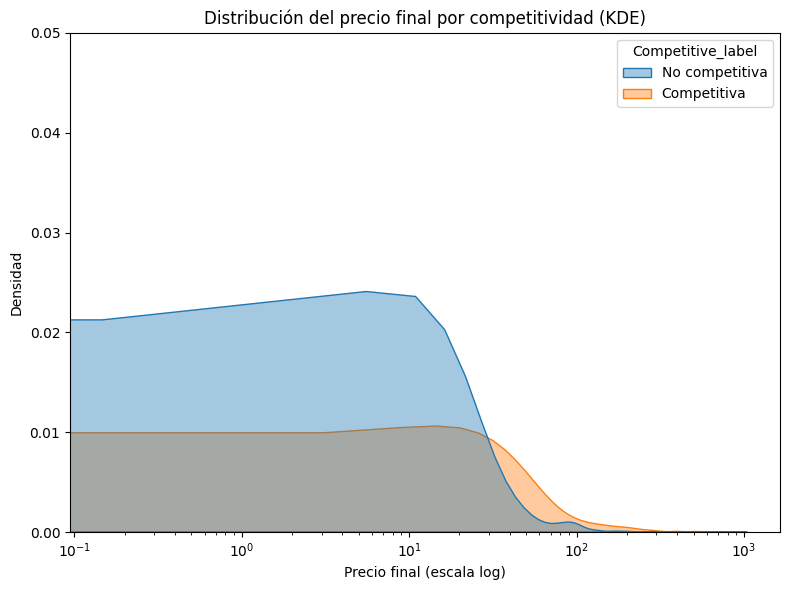

In [ ]:

df["Competitive_label"] = df["Competitive"].map({0: "No competitiva", 1: "Competitiva"})

plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df,
    x="ClosePrice",
    hue="Competitive_label",
    fill=True,
    alpha=0.4,
    palette=["#1f77b4", "#ff7f0e"],
    common_norm=False
)
s
plt.xscale('log')         
plt.ylim(0, 0.05)     
plt.title("Distribución del precio final por competitividad (KDE)")
plt.xlabel("Precio final (escala log)")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()


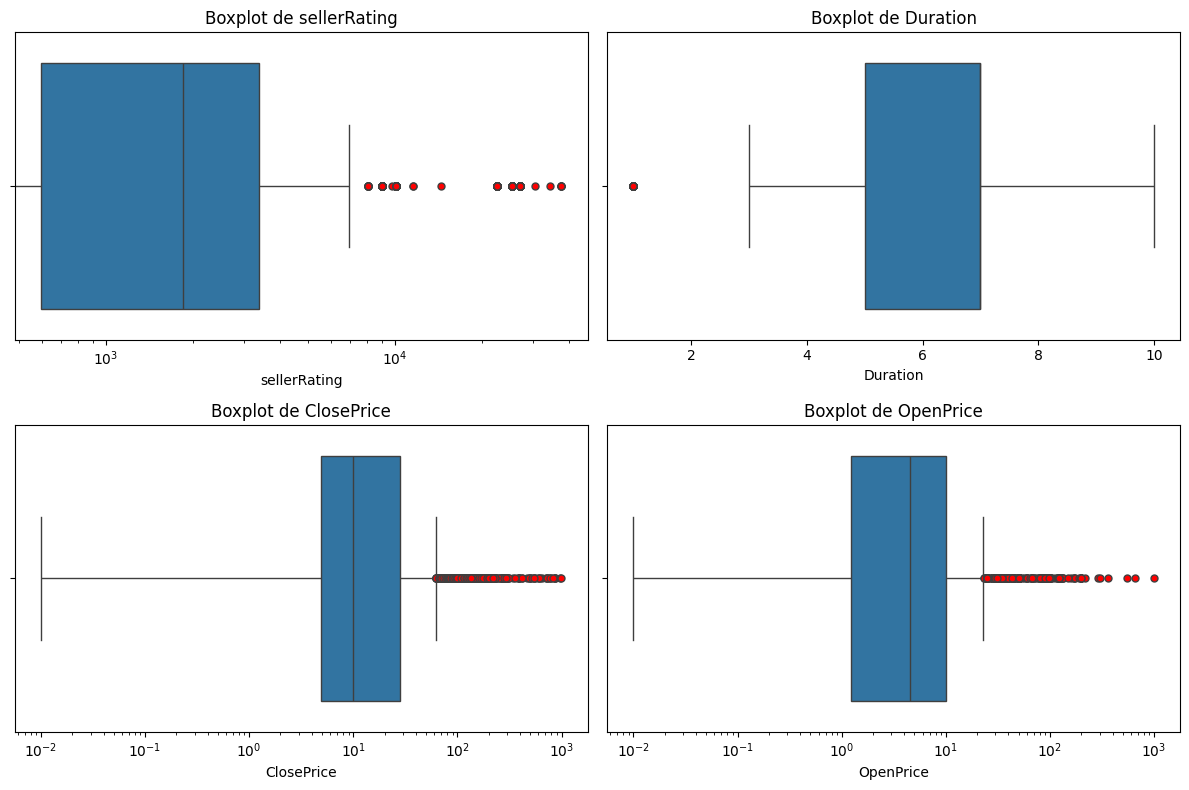

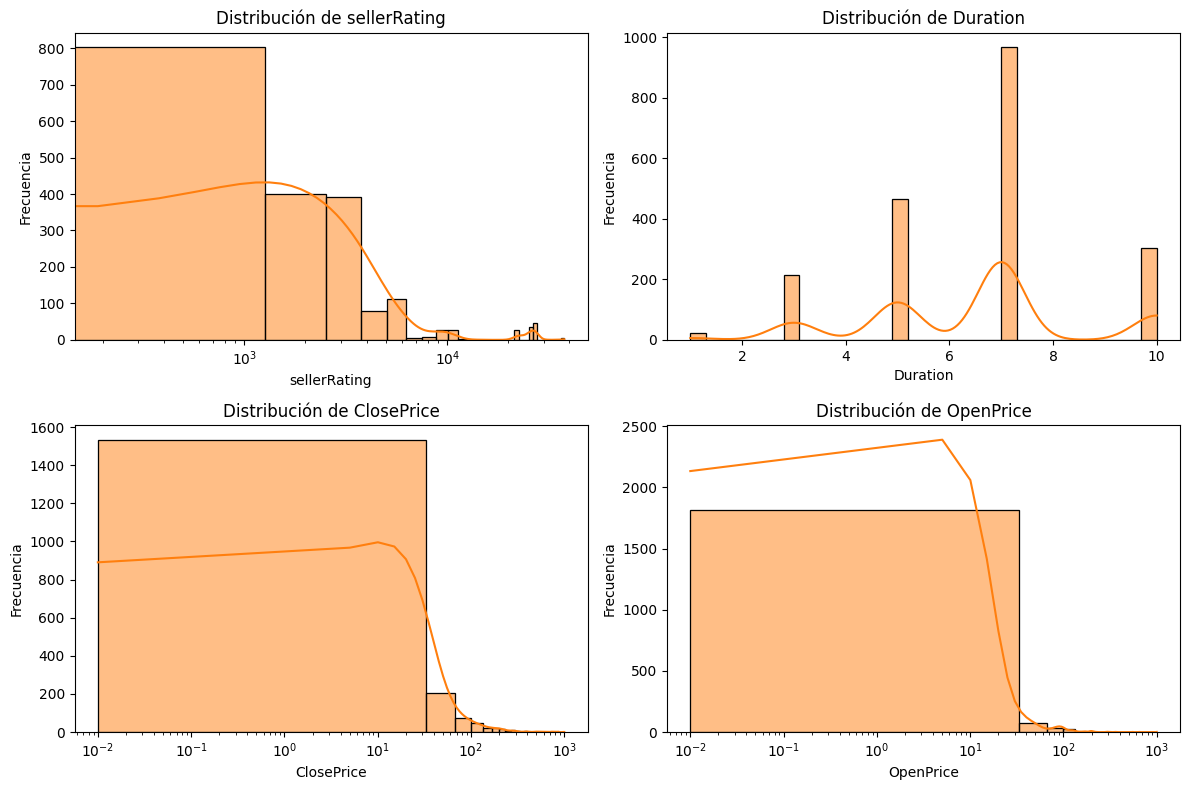

In [41]:

# === 2. Seleccionar columnas numéricas excepto 'Competitive' ===
num_cols = df.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if col != "Competitive"]

# === 3. --- Cuadrícula 2x2 de Boxplots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:4]):  # solo las primeras 4 si hay más
    sns.boxplot(
        x=df[col],
        orient="h",
        ax=axes[i],
        color="#1f77b4",
        flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5}
    )
    axes[i].set_title(f"Boxplot de {col}")
    if df[col].max() > df[col].median() * 20:
        axes[i].set_xscale('log')

plt.tight_layout()
plt.show()

# === 4. --- Cuadrícula 2x2 de distribuciones ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:4]):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i],
        color="#ff7f0e"
    )
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_ylabel("Frecuencia")
    if df[col].max() > df[col].median() * 20:
        axes[i].set_xscale('log')

plt.tight_layout()
plt.show()
